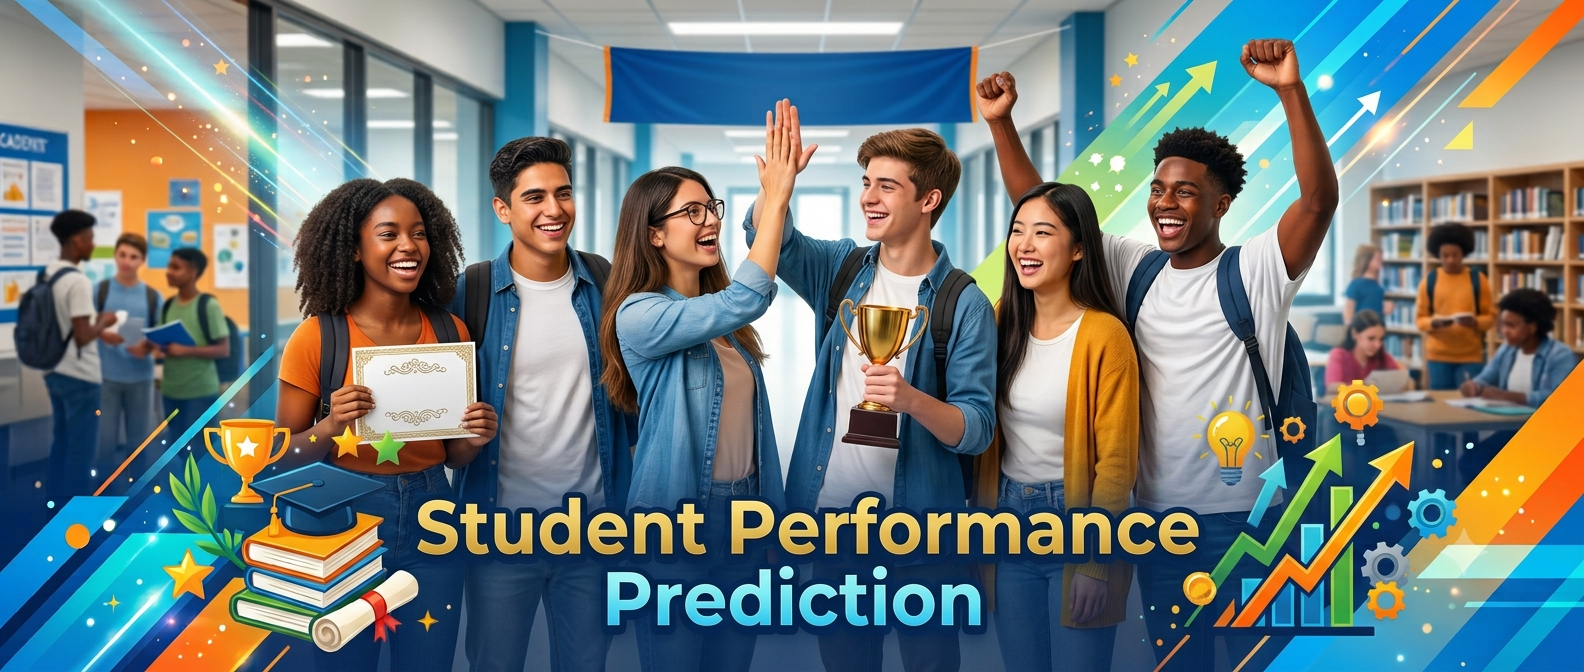

##  Student Final Exam Score Prediction Using Artificial Neural Network

## Problem Statement

Students' final exam performance can be influenced by several academic and lifestyle factors such as study hours, attendance, assignment performance, previous exam scores, sleep, screen time, class participation, and practice tests. However, it can be difficult to determine the final exam score based on these factors using simple analysis alone.

## Project Objective

The objective of this project is to develop an Artificial Neural Network (ANN) regression model that predicts a student's Final_Exam_Score based on their academic performance, study habits, attendance, and lifestyle-related factors.

The model will learn the relationship between these input features and the final exam score, allowing us to estimate a student's expected final exam performance.

### Input Features

- Study hours
- Attendance percentage
- Assignment average
- Previous exam score
- Sleep hours
- Screen time
- Class participation
- Practice tests completed
- Extracurricular hours
- Late submissions
- 🎯 Target

      Final_Exam_Score → Continuous numerical value

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [ ]:
df = pd.read_csv('student_performance.csv')

# Data Overview

In [ ]:
df.head(5)

,Study_Hours_Per_Day,Attendance_Percent,Assignment_Average,Previous_Exam_Score,Sleep_Hours,Screen_Time_Hours,Class_Participation_Score,Practice_Tests_Completed,Extracurricular_Hours_Per_Week,Late_Submissions,Final_Exam_Score
0,3.2,88.7,72.8,80.6,7.0,3.6,5,6,1.9,0,62.6
1,1.4,92.3,83.8,66.8,8.0,6.5,1,6,3.5,1,61.6
2,5.3,82.5,83.8,85.8,8.1,4.4,4,2,2.8,2,59.0
3,4.3,77.2,80.8,62.5,8.6,2.6,6,8,2.1,1,60.0
4,10.2,82.3,71.1,88.5,6.5,2.7,7,4,0.4,1,69.0


In [ ]:
df.shape

(7500, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Study_Hours_Per_Day             7500 non-null   float64
 1   Attendance_Percent              7500 non-null   float64
 2   Assignment_Average              7500 non-null   float64
 3   Previous_Exam_Score             7500 non-null   float64
 4   Sleep_Hours                     7500 non-null   float64
 5   Screen_Time_Hours               7500 non-null   float64
 6   Class_Participation_Score       7500 non-null   int64  
 7   Practice_Tests_Completed        7500 non-null   int64  
 8   Extracurricular_Hours_Per_Week  7500 non-null   float64
 9   Late_Submissions                7500 non-null   int64  
 10  Final_Exam_Score                7500 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 644.7 KB


In [ ]:
df.isnull().sum()

,0
Study_Hours_Per_Day,0
Attendance_Percent,0
Assignment_Average,0
Previous_Exam_Score,0
Sleep_Hours,0
Screen_Time_Hours,0
Class_Participation_Score,0
Practice_Tests_Completed,0
Extracurricular_Hours_Per_Week,0
Late_Submissions,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

## Univariate Analysis

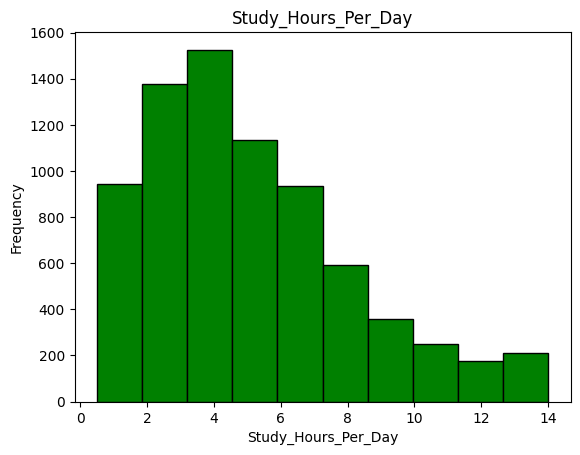

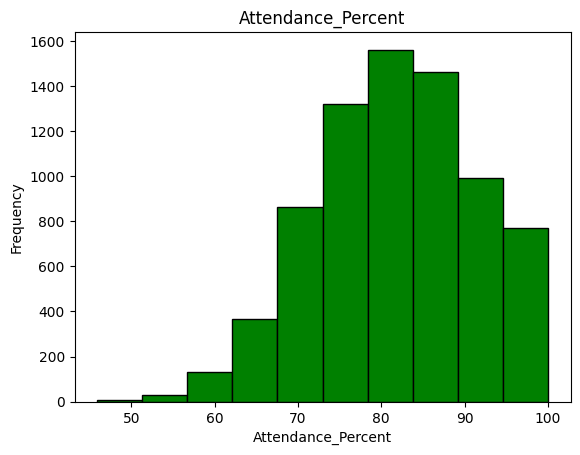

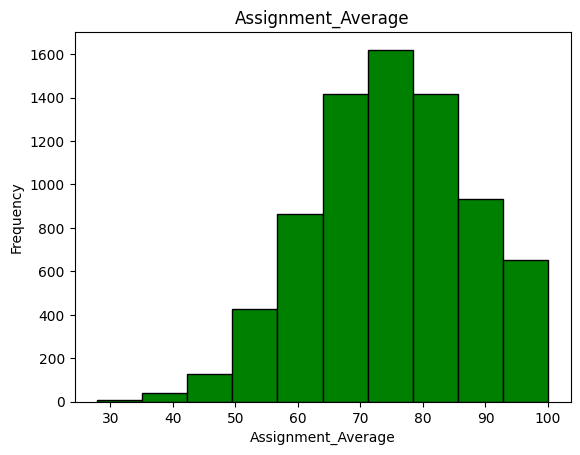

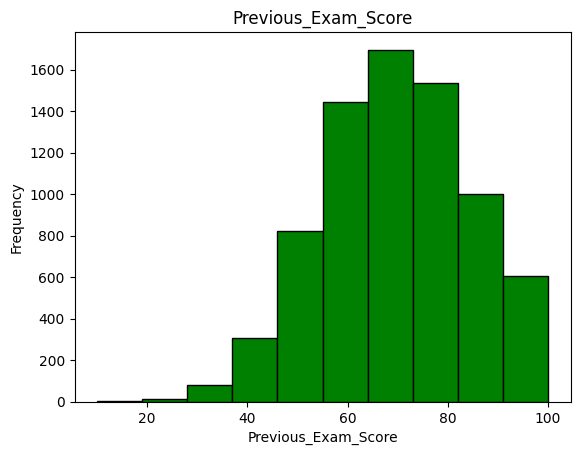

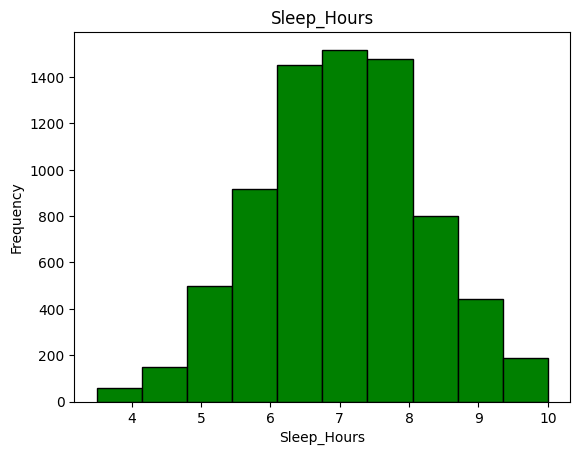

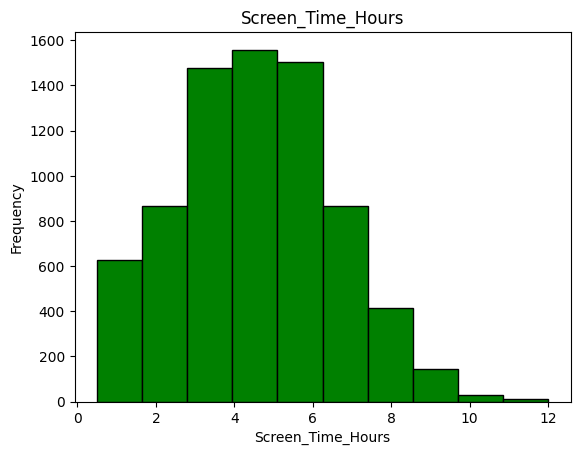

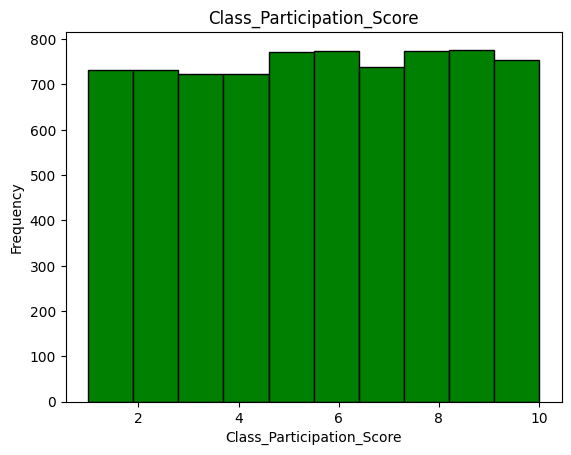

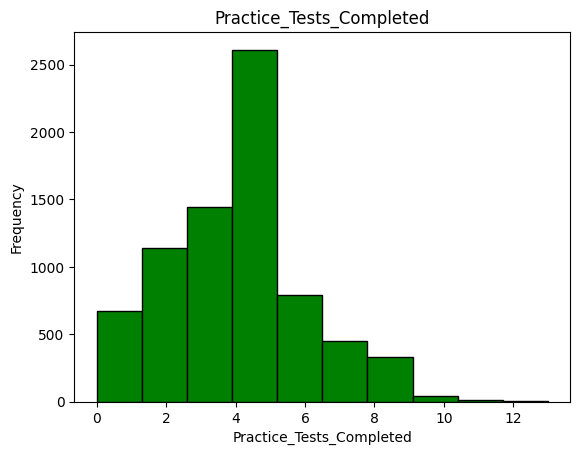

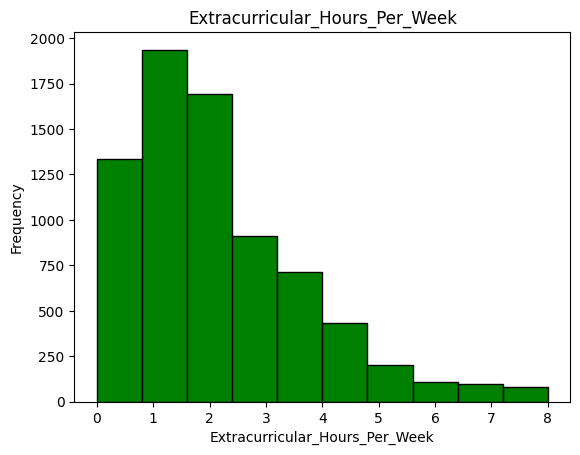

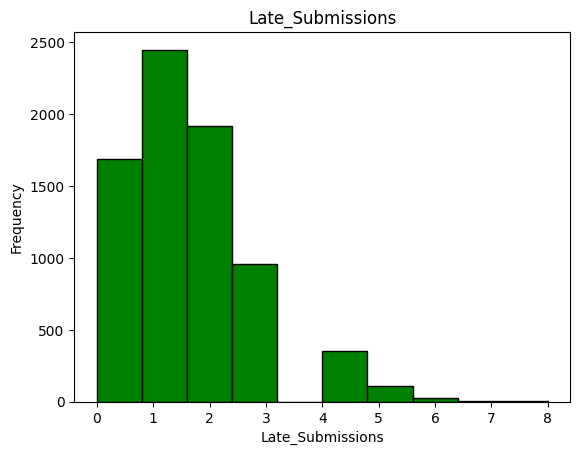

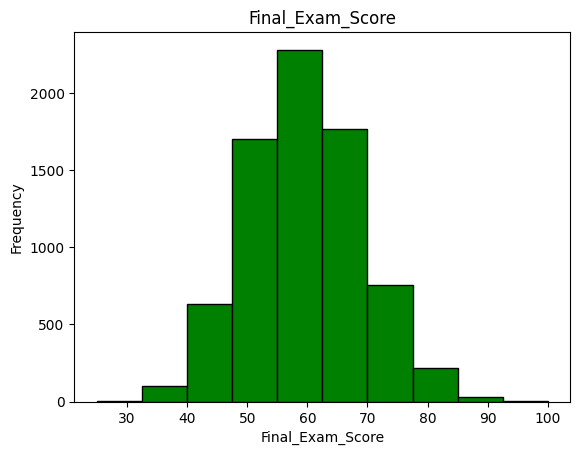

In [ ]:
cols = df.columns
for i in cols:
  plt.hist(df[i],edgecolor='black',color='green')
  plt.title(i)
  plt.xlabel(i)
  plt.ylabel("Frequency")
  plt.show()

In [ ]:
df.columns

Index(['Study_Hours_Per_Day', 'Attendance_Percent', 'Assignment_Average',
       'Previous_Exam_Score', 'Sleep_Hours', 'Screen_Time_Hours',
       'Class_Participation_Score', 'Practice_Tests_Completed',
       'Extracurricular_Hours_Per_Week', 'Late_Submissions',
       'Final_Exam_Score'],
      dtype='object')

## Bivariate Analysis

In [ ]:
pair_cols = [
    "Study_Hours_Per_Day",
    "Attendance_Percent",
    "Previous_Exam_Score",
    "Screen_Time_Hours",
    "Final_Exam_Score"
]

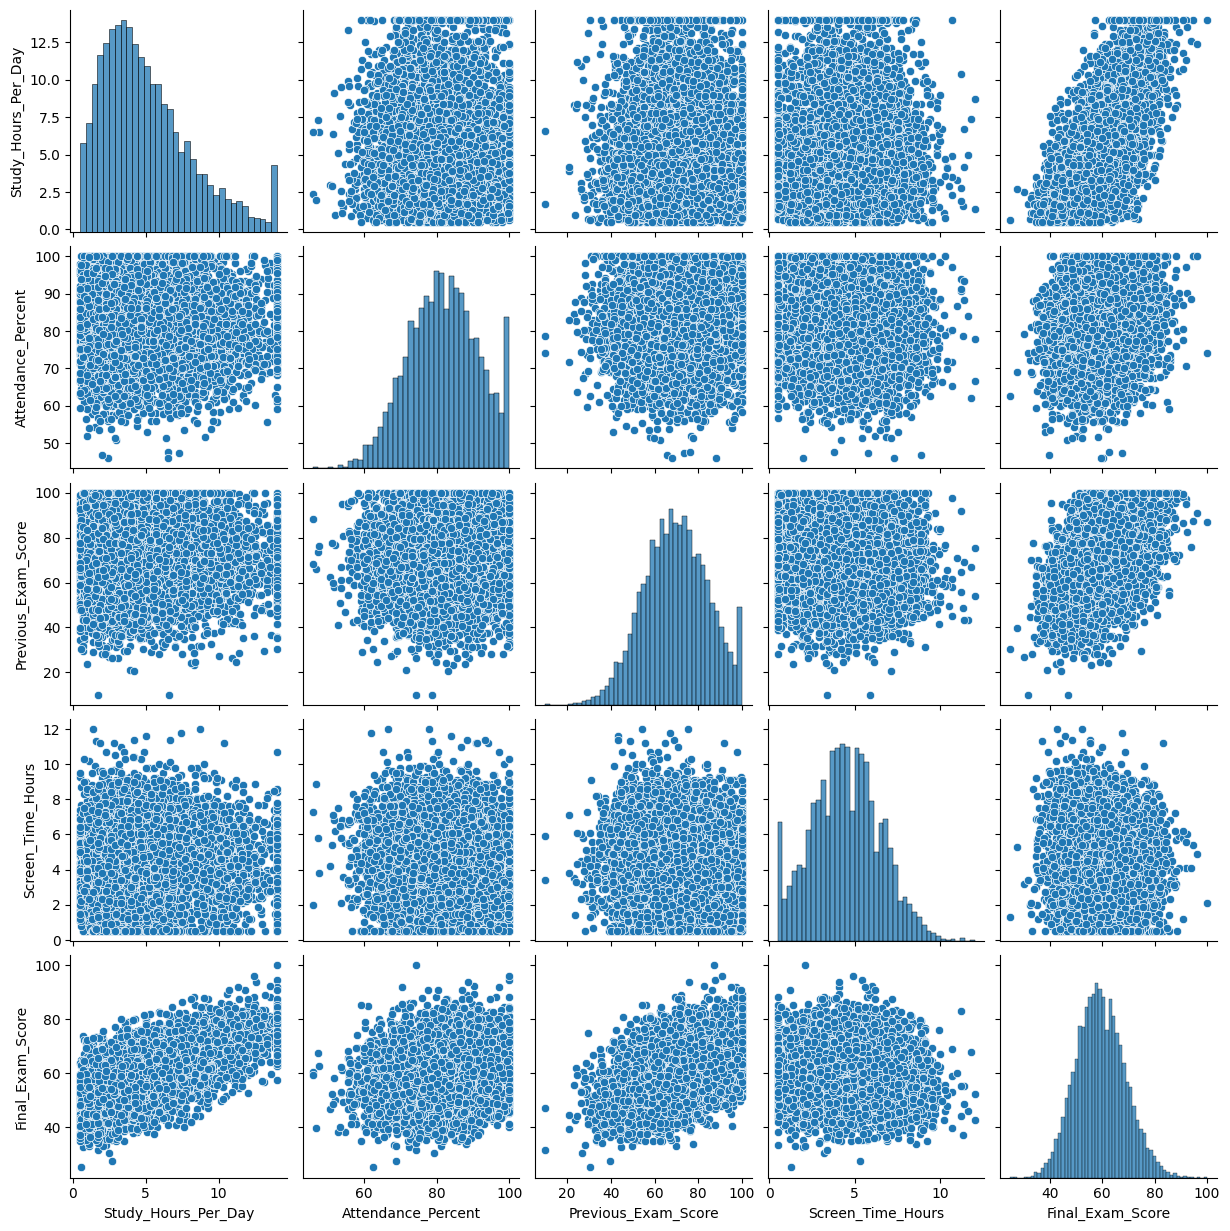

In [ ]:
import seaborn as sns
sns.pairplot(df[pair_cols])
plt.show()

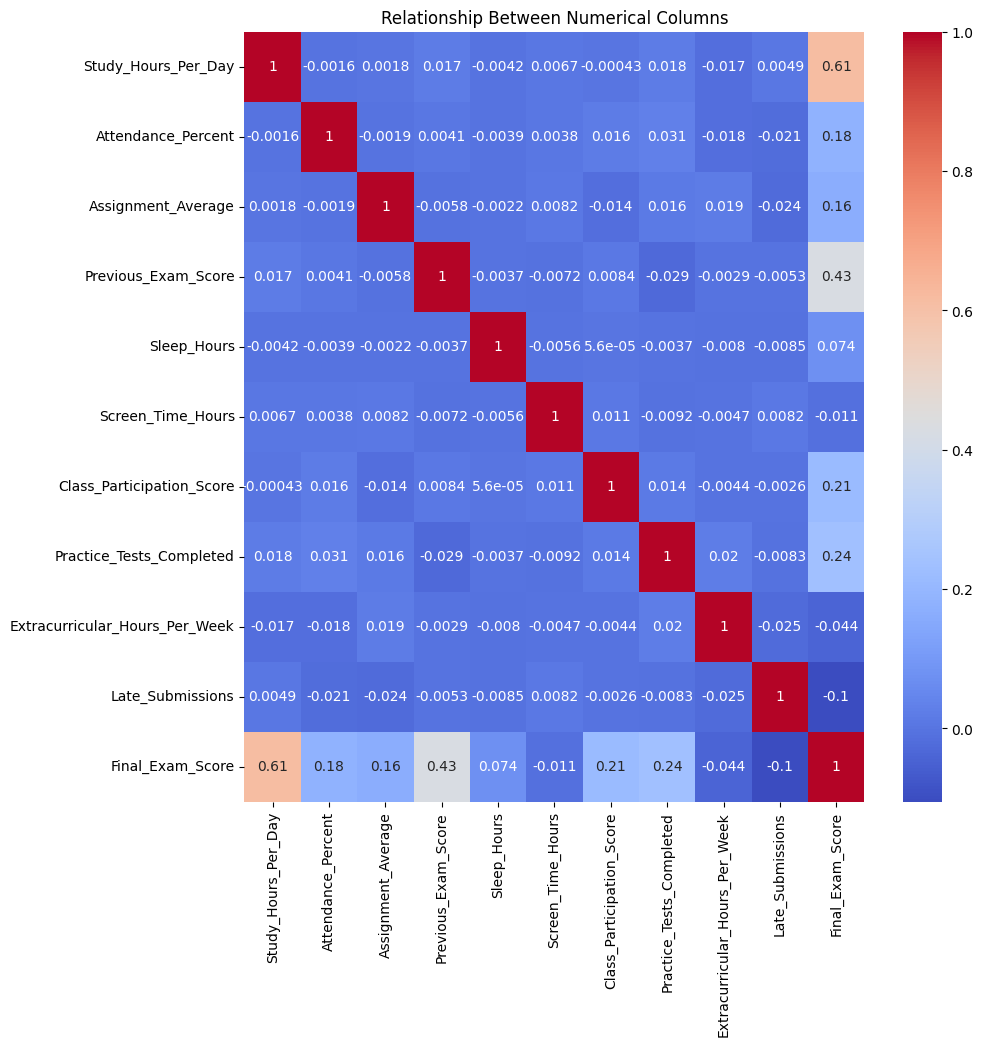

In [ ]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cmap='coolwarm',annot=True)
plt.title("Relationship Between Numerical Columns")
plt.show()

# Data Preprocessing

In [ ]:
x = df.drop(['Final_Exam_Score'],axis=1)
y = df['Final_Exam_Score']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model Building

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
model = Sequential(
    [
        Dense(64,activation='relu',input_shape=(10,)),
        Dropout(0.20),
        Dense(32,activation='relu'),
        Dropout(0.20),

        Dense(1,activation='linear')

    ]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae'])

In [ ]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    restore_best_weights=True,
    start_from_epoch=0
)

In [ ]:
history = model.fit(x_train,y_train,epochs=80,validation_split=0.2,callbacks=early_stopping,batch_size=20)

Epoch 1/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1819.9205 - mae: 37.7814 - val_loss: 117.4065 - val_mae: 8.7706
Epoch 2/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 178.7761 - mae: 10.6857 - val_loss: 87.2685 - val_mae: 7.4903
Epoch 3/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 164.3000 - mae: 10.2916 - val_loss: 76.4879 - val_mae: 7.0051
Epoch 4/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 152.3954 - mae: 9.8711 - val_loss: 64.7486 - val_mae: 6.4022
Epoch 5/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 142.6808 - mae: 9.5917 - val_loss: 56.7963 - val_mae: 6.0061
Epoch 6/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 130.0545 - mae: 9.1520 - val_loss: 52.6346 - val_mae: 5.7996
Epoch 7/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 123.6808 - mae: 8.8759 - val_loss: 44.5396 - val_mae: 5.3250
Epoch 8/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 112.5027 - mae: 8.4732 - val_loss: 42.5625 - val_mae: 5.2160
Epoch 9/80
225/225 ━━━━━━━━

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

# Visulization of Loss and MAE

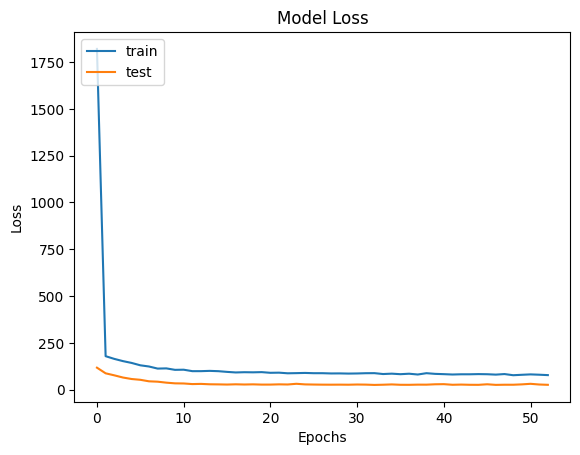

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train','test'],loc='upper left')
plt.show()

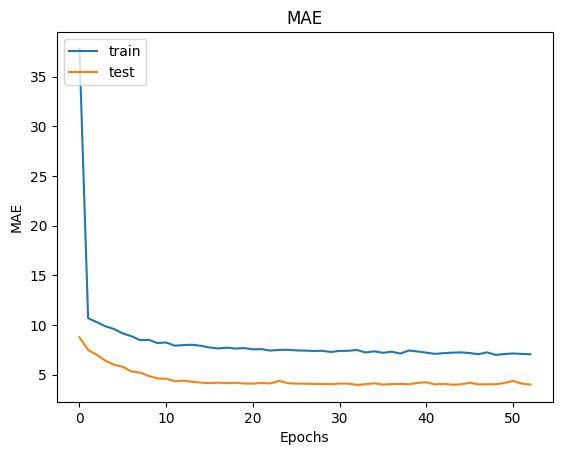

In [ ]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("MAE")
plt.legend(['train','test'],loc='upper left')
plt.show()

# Prediction

In [ ]:
y_pred = model.predict(x_test)

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


# Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")
print(f"R2: {r2_score(y_test,y_pred)}")

MAE: 4.0526482869466145
MSE: 25.78514301423914
R2: 0.7115357683556133


## Conclusion

This project successfully developed an Artificial Neural Network (ANN) model using TensorFlow to predict students' Final Exam Scores based on their academic and related features. The data was preprocessed and the input features were standardized before training the neural network.

The initial model produced a low R² score of 0.117, indicating that the model was not learning the relationships between the input features and the target effectively. After applying feature scaling and improving the training configuration, the model performance improved significantly.

The final model achieved an **MAE of 4.05**, **MSE of 25.79**, and an **R² score of 0.712** on the test data. This means the model was able to explain approximately 71.2% of the variation in Final Exam Scores, with an average prediction error of about 4.05 score units.

Overall, the project demonstrates how proper preprocessing, feature scaling, and an appropriately designed ANN can significantly improve the performance of a deep learning regression model on tabular data. It also provided practical experience in building, training, evaluating, and improving a TensorFlow-based neural network.
